<a href="https://colab.research.google.com/github/arunjthilak80/Data-Science-Projects/blob/main/SimpleLinearRegression_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the first assignment in Simple Linear Regression. The dataset used here is Insurance.csv (Medical cost personal dataset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

Step 1: Loading the dataset

In [3]:
df=pd.read_csv("/content/drive/MyDrive/SIMPLE LINEAR AND MULTIPLE LINEAR REGRESSION ASSIGNMENT/insurance.csv")

Step 2: Exploring the dataset

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Step 3: Preprocessing the dataset

(Converting Text to Numbers as Machine Learning models need numbers. Hence we convert 'sex', 'smoker', and 'region' from the dataset to numbers)

In [7]:
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

Step 4: Segregating the dataset into input and output

Define Features (X) and Target (y)

In [8]:
X = df.drop('charges', axis=1)
y = df['charges']

Step 5: Splitting the dataset into train and test.

(80% Train, 20% Test)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 6: Building and Training the model

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Step 7: Predicting the result using the trained model

In [12]:
predictions = model.predict(X_test)

Step 8: Evaluating the model

In [13]:
print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, predictions):.2f}")
print(f"R-squared Score: {r2_score(y_test, predictions):.4f}")


--- Model Evaluation ---
Mean Absolute Error: $4181.19
R-squared Score: 0.7836


Step 9: Visualizing the results

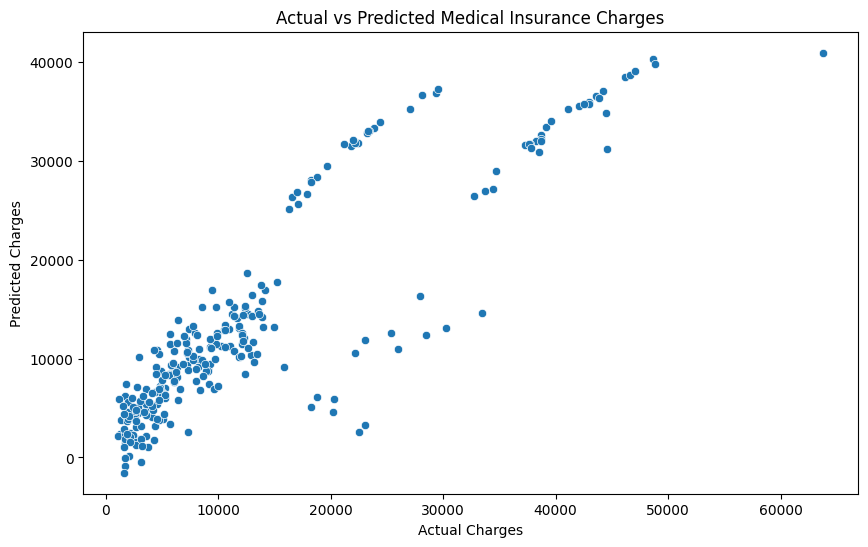

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Medical Insurance Charges')
plt.show()